2. Using data from dataloader (Data_loaders\dataloader_oil.py)

In [2]:
import sys

sys.path.insert(0, 'Data\raw')
sys.path.insert(0, 'Data_loaders')

In [3]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [4]:
import os
print("Current Working Directory:", os.getcwd())

print("Local Folder Contents:", os.listdir("."))

Current Working Directory: c:\Users\eye24\OneDrive\ドキュメント\GitHub\AI-Immigration\Visualisation_Board
Local Folder Contents: ['Bypass_Pipeline_Capacity_(Aston).ipynb', 'Change_in_Malacca_Volumes_(Akylai).ipynb', 'Cost-Burden_Analysis2_(Ai & Ririka).ipynb', 'Cost-Burden_Analysis_(Ai & Ririka).ipynb', 'Impacts_on_Global_Oil_Trade_(Mami).ipynb', 'Visualisation_Board']


In [5]:
import sys
from pathlib import Path

parent_dir = str(Path("..").resolve())

# 検索パスに登録
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 【★追加】さらに、その中にある Data_loaders 自体のパスも登録してみる
# (dataloader_oil.py が libraries を探せるようにするため)
data_loaders_dir = str((Path("..") / "Data_loaders").resolve())
if data_loaders_dir not in sys.path:
    sys.path.append(data_loaders_dir)

from Data_loaders import dataloader_oil

Check point for load_oil_prices
Check point for load_oil_prices_csv
Check point for _fallback_oil_prices


In [6]:
df = dataloader_oil.load_oil_prices()  

print(df.head())
print(df.info())

           date                                             region  \
797  1960-01-31  Crude oil price (USD/bbl) - World average - Wo...   
2391 1960-01-31  Crude oil price (USD/bbl) - Asia - World Bank ...   
1594 1960-01-31  Crude oil price (USD/bbl) - Europe - World Ban...   
1595 1960-02-29  Crude oil price (USD/bbl) - Europe - World Ban...   
2392 1960-02-29  Crude oil price (USD/bbl) - Asia - World Bank ...   

      price_usd_bbl  
797            1.63  
2391           1.63  
1594           1.63  
1595           1.63  
2392           1.63  
<class 'pandas.core.frame.DataFrame'>
Index: 2924 entries, 797 to 3984
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2924 non-null   datetime64[ns]
 1   region         2924 non-null   object        
 2   price_usd_bbl  2924 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 91.4+ KB
None


C:\Users\eye24\OneDrive\ドキュメント\GitHub\AI-Immigration\Data_loaders\dataloader_oil.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(


In [7]:
df.head()

,date,region,price_usd_bbl
797,1960-01-31,Crude oil price (USD/bbl) - World average - Wo...,1.63
2391,1960-01-31,Crude oil price (USD/bbl) - Asia - World Bank ...,1.63
1594,1960-01-31,Crude oil price (USD/bbl) - Europe - World Ban...,1.63
1595,1960-02-29,Crude oil price (USD/bbl) - Europe - World Ban...,1.63
2392,1960-02-29,Crude oil price (USD/bbl) - Asia - World Bank ...,1.63


In [8]:
df.tail()

,date,region,price_usd_bbl
1592,2026-04-30,Crude oil price (USD/bbl) - World average - Wo...,103.91
1593,2026-05-31,Crude oil price (USD/bbl) - World average - Wo...,100.43
3187,2026-05-31,Crude oil price (USD/bbl) - Asia - World Bank ...,94.67
2390,2026-05-31,Crude oil price (USD/bbl) - Europe - World Ban...,107.54
3984,2026-05-31,Crude oil price (USD/bbl) - North America - Wo...,99.09


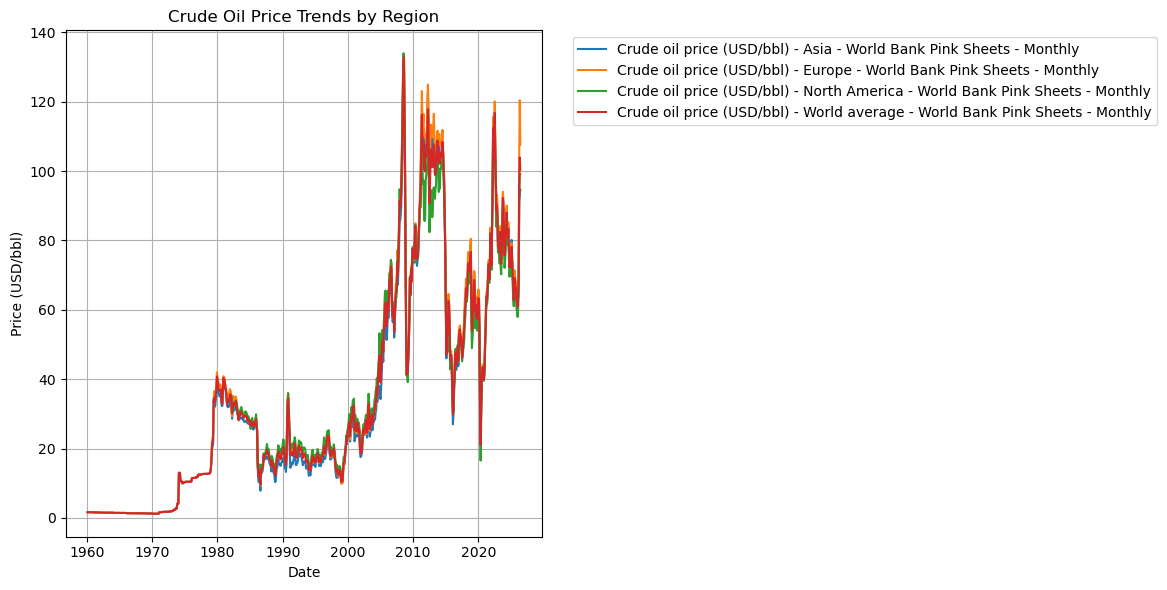

In [9]:
import matplotlib.pyplot as plt

# グラフのサイズを変更したい場合は、あらかじめ設定しておきます
plt.rcParams["figure.figsize"] = (12, 6)

# region（地域）ごとにグループ化して、それぞれの推移を折れ線グラフで描画
for region_name, group in df.groupby('region'):
    # x軸に日付、y軸に価格を指定
    plt.plot(group['date'], group['price_usd_bbl'], label=region_name)

# グラフのタイトルや軸ラベルの設定
plt.title('Crude Oil Price Trends by Region')
plt.xlabel('Date')
plt.ylabel('Price (USD/bbl)')

# 地域名（凡例）が重ならないように、グラフの外側（右側）に配置します
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 背景に目盛線（グリッド）を追加
plt.grid(True)

# レイアウトを自動調整
plt.tight_layout()

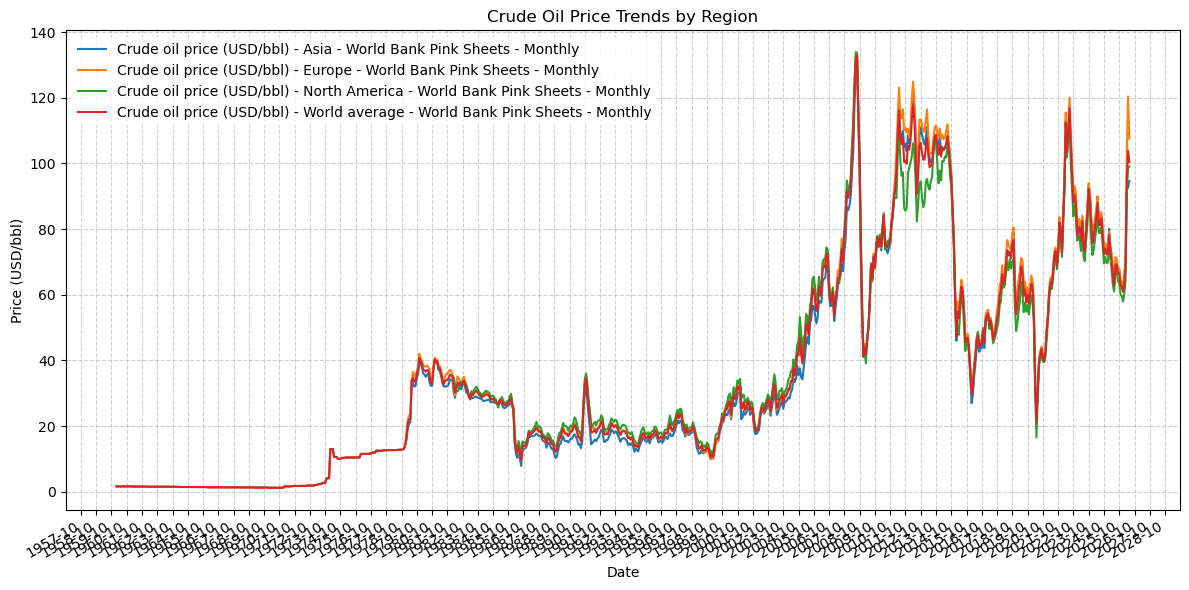

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # 日付目盛りを操作するためのモジュール

# グラフを描画する土台（figとax）を作成
fig, ax = plt.subplots(figsize=(12, 6))

# region（地域）ごとにグループ化してプロット
for region_name, group in df.groupby('region'):
    # plt.plot ではなく ax.plot を使います
    ax.plot(group['date'], group['price_usd_bbl'], label=region_name)

# --- ここからx軸の間隔・フォーマットの設定 ---

# ① 目盛りの間隔を「月ごと」に設定
# ※ もし表示期間が長すぎてラベルが重なる場合は、interval=3（3ヶ月ごと）や interval=12（1年ごと）などに調整してください
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))

# ② 日付の表示フォーマットを「年-月（例: 1960-01）」に設定
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# ③ 日付ラベルを少し斜めにして、重なりを防ぐ自動調整
fig.autofmt_xdate()

# --------------------------------------------

# グラフのタイトルや軸ラベルの設定
plt.title('Crude Oil Price Trends by Region')
plt.xlabel('Date')
plt.ylabel('Price (USD/bbl)')

# 凡例・グリッド・レイアウトの設定
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
